In [1]:
# ==========================================================
# CELL 1 : Import Required Libraries
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ==========================================================
# Set Random Seed for Reproducibility
# ==========================================================

import random
import tensorflow as tf

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Random Seed Fixed Successfully!")

Random Seed Fixed Successfully!


In [3]:
# ============================
# Load Preprocessed Dataset
# ============================

import joblib

X_train = joblib.load("Demand_X_train.pkl")
X_test = joblib.load("Demand_X_test.pkl")

y_train = joblib.load("Demand_y_train.pkl")
y_test = joblib.load("Demand_y_test.pkl")

print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)

print("\nTraining Target Shape :", y_train.shape)
print("Testing Target Shape  :", y_test.shape)

Training Features Shape : (100, 11)
Testing Features Shape  : (26, 11)

Training Target Shape : (100,)
Testing Target Shape  : (26,)


In [4]:
# ============================
# Feature Scaling
# ============================

from sklearn.preprocessing import MinMaxScaler

# Feature Scaler
X_scaler = MinMaxScaler()

X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

# Target Scaler
y_scaler = MinMaxScaler()

y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_test.values.reshape(-1, 1))

print("Feature Scaling Completed Successfully!")
print("X_train_scaled :", X_train_scaled.shape)
print("X_test_scaled  :", X_test_scaled.shape)

print("y_train_scaled :", y_train_scaled.shape)
print("y_test_scaled  :", y_test_scaled.shape)

Feature Scaling Completed Successfully!
X_train_scaled : (100, 11)
X_test_scaled  : (26, 11)
y_train_scaled : (100, 1)
y_test_scaled  : (26, 1)


In [5]:
# ============================
# Reshape Data for LSTM
# ============================

X_train_lstm = X_train_scaled.reshape(
    X_train_scaled.shape[0],
    1,
    X_train_scaled.shape[1]
)

X_test_lstm = X_test_scaled.reshape(
    X_test_scaled.shape[0],
    1,
    X_test_scaled.shape[1]
)

print("Training Shape :", X_train_lstm.shape)
print("Testing Shape  :", X_test_lstm.shape)

Training Shape : (100, 1, 11)
Testing Shape  : (26, 1, 11)


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.layers import GRU
from tensorflow.keras.callbacks import EarlyStopping

In [7]:
# ============================
# Build Baseline GRU Model
# ============================

model = Sequential()

# GRU Layer
model.add(
    GRU(
        units=64,
        activation='tanh',
        input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])
    )
)

# Dropout Layer
model.add(Dropout(0.3))

# Output Layer
model.add(Dense(1))

# Compile Model
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

model.compile(
    optimizer=optimizer,
    loss='mse'
)

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        14,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,849 (58.00 KB)

 Trainable params: 14,849 (58.00 KB)

 Non-trainable params: 0 (0.00 B)

None


In [8]:
# ============================
# Train LSTM Model
# ============================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    X_train_lstm,
    y_train_scaled,
    epochs=200,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - loss: 0.0410 - val_loss: 0.0155
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0251 - val_loss: 0.0150
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0218 - val_loss: 0.0271
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0134 - val_loss: 0.0186
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0177 - val_loss: 0.0157
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0129 - val_loss: 0.0224
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0109 - val_loss: 0.0185
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0155 - val_loss: 0.0075
Epoch 9/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0114 - val_loss: 0.0132
Epoch 10/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0125 - val_loss: 0.0131
Epoch 11/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0116 - val_loss: 0.0086
Epoch 12/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

In [9]:
# ============================
# Make Predictions
# ============================

# Training Predictions
train_predictions = model.predict(X_train_lstm)

# Testing Predictions
test_predictions = model.predict(X_test_lstm)

# Convert predictions back to original scale
train_predictions = y_scaler.inverse_transform(train_predictions)
test_predictions = y_scaler.inverse_transform(test_predictions)

# Convert actual values back to original scale
y_train_actual = y_scaler.inverse_transform(y_train_scaled)
y_test_actual = y_scaler.inverse_transform(y_test_scaled)

print("Prediction Completed Successfully!")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Prediction Completed Successfully!


In [10]:
# ============================
# Model Evaluation
# ============================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score
)

import numpy as np

# -----------------------------
# Training Metrics
# -----------------------------
train_mae = mean_absolute_error(y_train_actual, train_predictions)
train_rmse = np.sqrt(mean_squared_error(y_train_actual, train_predictions))
train_mape = mean_absolute_percentage_error(y_train_actual, train_predictions) * 100
train_r2 = r2_score(y_train_actual, train_predictions)

print("=" * 50)
print("Training Performance")
print("=" * 50)
print(f"MAE  : {train_mae:.2f}")
print(f"RMSE : {train_rmse:.2f}")
print(f"MAPE : {train_mape:.2f}%")
print(f"R²   : {train_r2:.4f}")

# -----------------------------
# Testing Metrics
# -----------------------------
test_mae = mean_absolute_error(y_test_actual, test_predictions)
test_rmse = np.sqrt(mean_squared_error(y_test_actual, test_predictions))
test_mape = mean_absolute_percentage_error(y_test_actual, test_predictions) * 100
test_r2 = r2_score(y_test_actual, test_predictions)

print("\n")
print("=" * 50)
print("Testing Performance")
print("=" * 50)
print(f"MAE  : {test_mae:.2f}")
print(f"RMSE : {test_rmse:.2f}")
print(f"MAPE : {test_mape:.2f}%")
print(f"R²   : {test_r2:.4f}")

Training Performance
MAE  : 107.81
RMSE : 130.45
MAPE : 1.21%
R²   : 0.9806


Testing Performance
MAE  : 59.97
RMSE : 73.50
MAPE : 0.56%
R²   : 0.9944


In [11]:
# ============================
# Save the Scalers
# ============================

import joblib

# Save Feature Scaler
joblib.dump(X_scaler, "Demand_X_Scaler.pkl")

# Save Target Scaler
joblib.dump(y_scaler, "Demand_y_Scaler.pkl")

print("Scalers Saved Successfully!")

Scalers Saved Successfully!


In [12]:
print(X_train.columns.tolist())

['Humidity', 'Rainfall', 'Electricity_Supply', 'Solar_Irradiance', 'Temperature', 'Year', 'Month_sin', 'Month_cos', 'Demand_Lag_1', 'Demand_Lag_2', 'Demand_Lag_3']


In [14]:
%whos

Variable                         Type             Data/Info
-----------------------------------------------------------
Dense                            type             <class 'keras.src.layers.core.dense.Dense'>
Dropout                          type             <class 'keras.src.layers.<...>ization.dropout.Dropout'>
EarlyStopping                    type             <class 'keras.src.callbac<...>_stopping.EarlyStopping'>
GRU                              type             <class 'keras.src.layers.rnn.gru.GRU'>
LSTM                             type             <class 'keras.src.layers.rnn.lstm.LSTM'>
MinMaxScaler                     type             <class 'sklearn.preproces<...>sing._data.MinMaxScaler'>
SEED                             int              42
Sequential                       type             <class 'keras.src.models.sequential.Sequential'>
X_scaler                         MinMaxScaler     MinMaxScaler()
X_test                           DataFrame             Humidity    Rain

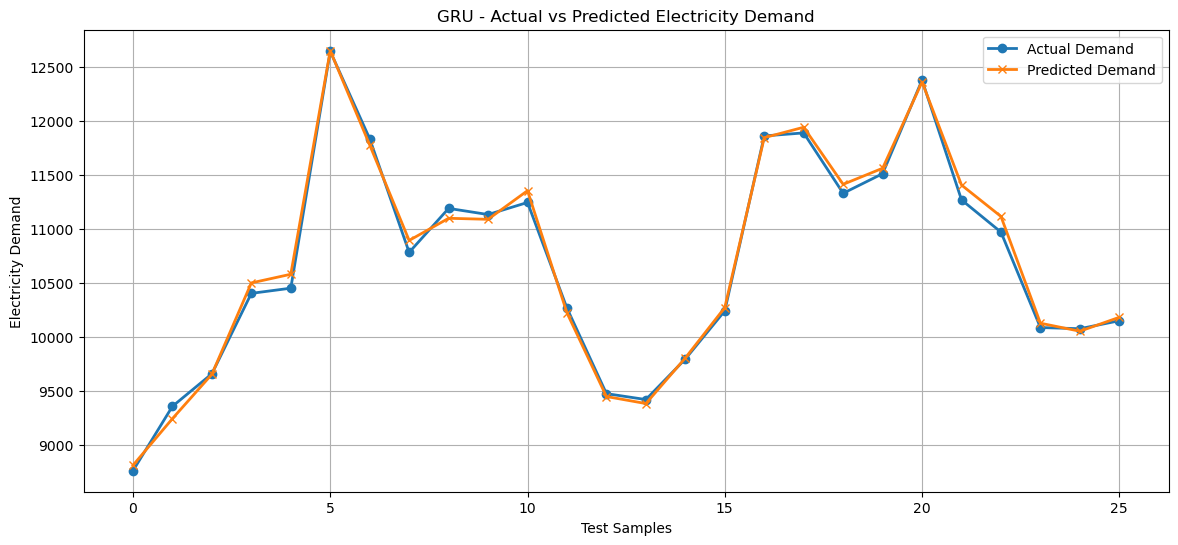

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    y_test_actual.flatten(),
    label="Actual Demand",
    linewidth=2,
    marker='o'
)

plt.plot(
    test_predictions.flatten(),
    label="Predicted Demand",
    linewidth=2,
    marker='x'
)

plt.title("GRU - Actual vs Predicted Electricity Demand")
plt.xlabel("Test Samples")
plt.ylabel("Electricity Demand")
plt.legend()
plt.grid(True)

plt.show()

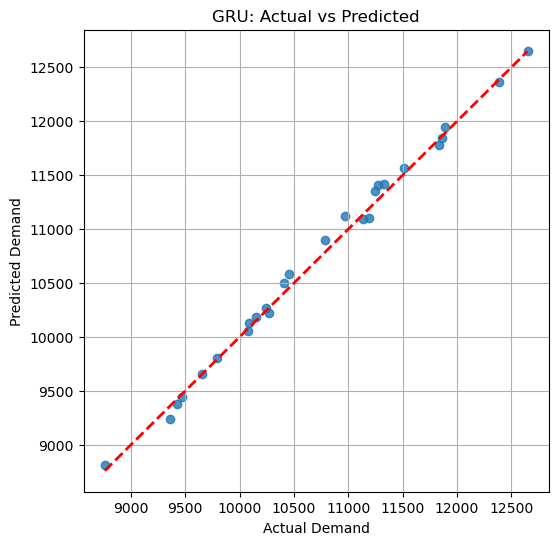

In [17]:
plt.figure(figsize=(6,6))

plt.scatter(y_test_actual, test_predictions, alpha=0.8)

plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("GRU: Actual vs Predicted")
plt.grid(True)

plt.show()

In [18]:
# saving the model 
model.save("GRU_Demand_Forecasting_09944.keras")